# Triplet Loss
Triplet loss is designed for metric learning, where the goal is to learn a feature space (embedding) in which similar items are close together and dissimilar items are far apart.

In our case, a triplet data point is defined as follows:

*   Anchor (A): One image of a flower from a specific class (e.g., a daffodil).
*   Positive (P): Another image from the same class (e.g., another daffodil — even if it’s not the same exact flower).
*   Negative (N): An image from a different class (e.g., a tulip or rose).







In [ ]:
import os
os.environ['PYTORCH_CUDA_ALLOC_CONF'] = 'expandable_segments:True'

In [ ]:
# Check colab's gpu
!nvidia-smi

Tue Nov 11 08:34:48 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   61C    P8             12W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from torchvision import datasets, transforms, models
import numpy as np
import random
import gc
import torch
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from collections import defaultdict

# Semi-hard triplet mining + Classification head

Following are some defintions for better understanding of the model:

1.   BATCH_SIZE: number of inputs per batch. Batch size should not be too small or else triplets formed for each batch may not be informative, batche size should not be too big as it will require more computational resources and duration.
2.   IMAGE_SIZE: Size of each image
3.   EMBEDDING_DIM: dimension of the feature vector that represents each image in the embedding space.
4.   DEVICE: Colab's T4 GPU is used for this notebook
5.   MARGIN: A sclar that describe the minimum difference that anchor-positive and anchor-negative distance must have
6.   TRIPLET_LR: Learning rate when training the embedding model using triplet loss, TRIPLET_LR is small for stable metric learning.
7.   CLASSIFICATION_LR: Learning rate when training classification layer

In [ ]:
BATCH_SIZE = 64
IMAGE_SIZE = 224  # Standard ResNet size
EMBEDDING_DIM = 512
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
MARGIN = 0.3
TRIPLET_LR = 0.0001
CLASSIFICATION_LR = 0.001

Semi-Hard triplet mining strategy has the following procedure:


1.	Each image is selected as the anchor once.
2.	For each anchor, select one image from the same class as positives.
3.	For each anchor, look for semi-hard negatives, which are defined as images that are further than the positive but still within the pre-defined margin i.e they satisfy d(A,P) < d(A,N) < d(A,P)+α where alpha is the margin.
4.	Among the discovered semi-hard negatives, choose the sample that has the closest distance to the anchor (hardest) to represent as the negative of the triplet.


**Initially, embedding is random, embedding layer will be updated by optimizing triplet loss**



In [ ]:
def mine_semi_hard_triplets_in_batch(embeddings, labels, margin):
    """
    Mine semi-hard triplets within a single batch of 64 images.
    Stores indices.
    """
    batch_size = embeddings.size(0)
    device = embeddings.device

    # Calculate distance matrix
    dist_matrix = torch.cdist(embeddings, embeddings, p=2)

    # Store indices instead of tensors to avoid dimension issues
    triplet_indices = []

    for i in range(batch_size):
        anchor_label = labels[i]

        # Create indices
        batch_indices = torch.arange(batch_size, device=device)

        # Find all positives (same class) in this batch
        positive_mask = (labels == anchor_label) & (batch_indices != i)
        positive_indices = torch.where(positive_mask)[0]

        if len(positive_indices) == 0:
            continue

        # Find all negatives (different class) in this batch
        negative_mask = labels != anchor_label
        negative_indices = torch.where(negative_mask)[0]

        if len(negative_indices) == 0:
            continue

        # For each positive, find semi-hard negatives
        for pos_idx in positive_indices:
            positive_distance = dist_matrix[i, pos_idx]

            # Find negatives that satisfy: d(a,p) < d(a,n) < d(a,p) + margin
            negative_distances = dist_matrix[i, negative_indices]
            semi_hard_mask = (negative_distances > positive_distance) & \
                            (negative_distances < positive_distance + margin)
            semi_hard_negatives = negative_indices[semi_hard_mask]

            if len(semi_hard_negatives) > 0:
                # Use the hardest semi-hard negative (smallest distance)
                hardest_negative_idx = semi_hard_negatives[torch.argmin(negative_distances[semi_hard_mask])]
                triplet_indices.append((i, pos_idx.item(), hardest_negative_idx.item()))
            else:
                # use random hard negative for fall back
                random_negative_idx = negative_indices[torch.randint(0, len(negative_indices), (1,))]
                triplet_indices.append((i, pos_idx.item(), random_negative_idx.item()))

    if not triplet_indices:
        return None

    # Extract embeddings using indices
    anchor_indices = [idx[0] for idx in triplet_indices]
    positive_indices = [idx[1] for idx in triplet_indices]
    negative_indices = [idx[2] for idx in triplet_indices]

    anchors = embeddings[anchor_indices]
    positives = embeddings[positive_indices]
    negatives = embeddings[negative_indices]

    return anchors, positives, negatives

def train_with_semi_hard_mining(dataloader, model, triplet_loss_fn, optimizer, scaler):
    """
    Training loop with online semi-hard mining - FIXED VERSION
    """
    model.train()
    total_loss = 0
    num_batches_processed = 0
    num_triplets_used = 0

    for batch, (images, labels) in enumerate(dataloader):
        try:
            images, labels = images.to(DEVICE), labels.to(DEVICE)

            with torch.amp.autocast('cuda'):
                # Get embeddings for all images in batch
                embeddings = model(images, return_embedding=True)

                # Online semi-hard mining within batch
                mined_triplets = mine_semi_hard_triplets_in_batch(embeddings, labels, MARGIN)

                if mined_triplets is not None:
                    anchor_emb, positive_emb, negative_emb = mined_triplets
                    loss = triplet_loss_fn(anchor_emb, positive_emb, negative_emb)

                    # Check for valid loss
                    if not torch.isnan(loss) and loss > 0:
                        scaler.scale(loss).backward()
                        num_triplets_used += anchor_emb.size(0)
                        total_loss += loss.item()

                        # Gradient accumulation
                        if (batch + 1) % 2 == 0:
                            scaler.step(optimizer)
                            scaler.update()
                            optimizer.zero_grad()

                        num_batches_processed += 1
                else:
                    # Reset gradients even whhen no triplets found
                    optimizer.zero_grad()

        except Exception as e:
            print(f"Error in batch {batch}: {e}")
            optimizer.zero_grad()
            continue

        if batch % 10 == 0:
            gc.collect()
            if torch.cuda.is_available():
                torch.cuda.empty_cache()

    avg_loss = total_loss / max(num_batches_processed, 1)
    return avg_loss, num_triplets_used

The model is designed as follows:


1.   A pretrained ResNet-50 backbone, with its final classification layer removed, for feature extraction.
2.   An embedding layer, trained using triplet loss, to learn a good representation embedding to represent each image in the embedding space.
3.   A two-layer perceptron classification head, which maps the learnt embeddings to class probabilities for image classification.



In [ ]:
class EmbeddingModelWithClassifier(nn.Module):
    def __init__(self, embedding_dim=512, num_classes=102):
        super().__init__()
        backbone = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
        self.features = nn.Sequential(*list(backbone.children())[:-1])  # Remove final FC layer


        with torch.no_grad():
            dummy_input = torch.randn(1, 3, IMAGE_SIZE, IMAGE_SIZE)
            feature_dim = self.features(dummy_input).view(1, -1).size(1)

        # Embedding layer with regularization
        self.embedding = nn.Sequential(
            nn.Linear(feature_dim, embedding_dim),
            nn.BatchNorm1d(embedding_dim),
            nn.Dropout(0.3)
        )

        # Classifier with regularization
        self.classifier = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(embedding_dim, 256),  # Added intermediate layer
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.5),  # Additional dropout
            nn.Linear(256, num_classes)  # Final classification layer
        )

    def forward(self, x, return_embedding=False):
        features = self.features(x)
        features = features.view(features.size(0), -1)
        embeddings = F.normalize(self.embedding(features), p=2, dim=1)

        if return_embedding:
            return embeddings
        else:
            return self.classifier(embeddings)

In [ ]:
# Used for back-propogation and update the model
class TripletLoss(nn.Module):
    def __init__(self, margin=0.2):
        super().__init__()
        self.margin = margin

    def forward(self, anchor, positive, negative):
        pos_dist = F.pairwise_distance(anchor, positive, p=2)
        neg_dist = F.pairwise_distance(anchor, negative, p=2)

        # Add small epsilon for numerical stability
        losses = F.relu(pos_dist - neg_dist + self.margin + 1e-8)

        # Check for null
        if torch.isnan(losses).any():
            return torch.tensor(0.0, device=anchor.device, requires_grad=True)

        return losses.mean()


In [ ]:
# To check if embedding is correct
def validate_embeddings(dataloader, model):
    """Validate embedding quality with simple retrieval metrics"""
    model.eval()
    all_embeddings = []
    all_labels = []

    with torch.no_grad():
        for images, labels in dataloader:
            embeddings = model(images.to(DEVICE), return_embedding=True)
            all_embeddings.append(embeddings.cpu())
            all_labels.append(labels)

    all_embeddings = torch.cat(all_embeddings)
    all_labels = torch.cat(all_labels)

    # Compute simple retrieval metrics
    dist_matrix = torch.cdist(all_embeddings, all_embeddings)

    # For each sample, check if nearest neighbor has same class
    nn_correct = 0
    for i in range(len(all_embeddings)):
        # Skip self
        dists = dist_matrix[i].clone()
        dists[i] = float('inf')
        nn_idx = torch.argmin(dists)
        if all_labels[nn_idx] == all_labels[i]:
            nn_correct += 1

    accuracy = 100.0 * nn_correct / len(all_embeddings)
    return accuracy

In [ ]:
# For training classification head
def train_classification_loop(dataloader, model, loss_fn, optimizer, scaler):
    """Train the classification head"""
    model.train()
    total_loss = 0
    correct = 0
    total = 0

    for batch, (images, labels) in enumerate(dataloader):
        images, labels = images.to(DEVICE), labels.to(DEVICE)

        with torch.amp.autocast('cuda'):
            outputs = model(images)  # Classification output
            loss = loss_fn(outputs, labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        optimizer.zero_grad()

        total_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    accuracy = 100. * correct / total
    return total_loss / len(dataloader), accuracy


def evaluate_model(dataloader, model, loss_fn):
    """Evaluate model with classification head"""
    model.eval()
    total_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in dataloader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)

            with torch.amp.autocast('cuda'):
                outputs = model(images)
                loss = loss_fn(outputs, labels)

            total_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

    accuracy = 100. * correct / total
    return total_loss / len(dataloader), accuracy

In [ ]:
def main():
    print(f"Using device: {DEVICE}")
    print(f"Embedding dimension: {EMBEDDING_DIM}")
    print(f"Margin: {MARGIN}")
    print(f"Strategy: Semi-Hard Mining + Classification Head")

    # Data augmentation since each class only have 10 samples - may not be enough
    transform = transforms.Compose([
        transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
        transforms.RandomHorizontalFlip(0.5),
        transforms.ColorJitter(0.3, 0.3, 0.3, 0.1),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])

    # Load datasets
    train_dataset = datasets.Flowers102('data', split='train', download=True, transform=transform)
    val_dataset = datasets.Flowers102('data', split='val', download=True, transform=transform)
    test_dataset = datasets.Flowers102('data', split='test', download=True, transform=transform)

    # Lists to store training history
    triplet_losses = []
    classification_train_accs = []
    classification_val_accs = []
    mining_stats = []  # Track mining effectiveness
    embedding_val_accs = []  # Track embedding quality

    # Create dataloaders
    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
    val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
    test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)


    print("\n" + "="*60)
    print("STAGE 1: SEMI-HARD MINING TRAINING")
    print("="*60)

    # Create model (we are trying to build this)
    model = EmbeddingModelWithClassifier(embedding_dim=EMBEDDING_DIM, num_classes=102).to(DEVICE)
    triplet_loss_fn = TripletLoss(margin=MARGIN)

    # Freeze classifier and train only restnet50 backbone + embedding
    embedding_params = []
    for name, param in model.named_parameters():
        if 'classifier' not in name:
            param.requires_grad = True
            embedding_params.append(param)
        else:
            param.requires_grad = False

    # Create optimizer to train embedding layer after parameter freezing
    optimizer = optim.Adam(embedding_params, lr=TRIPLET_LR, weight_decay=0.01)
    scaler = torch.amp.GradScaler('cuda')

    # early stopping for building embedding layer
    best_embedding_acc = 0
    patience = 4  # Stop if no improvement for 4 epochs
    patience_counter = 0
    early_stop_triggered = False

    print("Training embeddings with semi-hard mining and early stopping...")
    for epoch in range(40):
        # Train with semi-hard mining
        train_loss, num_triplets = train_with_semi_hard_mining(
            train_loader, model, triplet_loss_fn, optimizer, scaler
        )

        # Validate embedding quality, same class should be neighbours
        embedding_acc = validate_embeddings(val_loader, model)

        triplet_losses.append(train_loss)
        mining_stats.append(num_triplets)
        embedding_val_accs.append(embedding_acc)

        print(f"Semi-Hard Epoch {epoch+1}: Loss: {train_loss:.4f}, "
              f"Triplets: {num_triplets}, Embedding Acc: {embedding_acc:.2f}%")

        # early stopping logic for embedding model
        if embedding_acc > best_embedding_acc:
            best_embedding_acc = embedding_acc
            patience_counter = 0
            # Save best embedding model
            torch.save(model.state_dict(), 'best_embedding_model.pth')
            print(f"  ↳ New best embedding accuracy! Saving model...")
        else:
            patience_counter += 1
            print(f"  ↳ No improvement for {patience_counter} epoch(s)")

        # Check early stopping condition
        if patience_counter >= patience:
            print(f"Early stopping triggered at epoch {epoch+1}")
            print(f"Best embedding accuracy: {best_embedding_acc:.2f}%")
            early_stop_triggered = True
            break

    # load best model
    if early_stop_triggered:
        print("Loading best embedding model for classification training...")
        model.load_state_dict(torch.load('best_embedding_model.pth'))

    print("\n" + "="*60)
    print("STAGE 2: CLASSIFICATION HEAD TRAINING")
    print("="*60)

    # Unfreeze classifier and freeze backbone for fine-tuning of classfier
    for name, param in model.named_parameters():
        if 'classifier' in name:
            param.requires_grad = True  # Train classifier
        else:
            param.requires_grad = False  # Freeze backbone

    # optimizer for classifier
    classifier_optimizer = optim.Adam(model.classifier.parameters(), lr=CLASSIFICATION_LR, weight_decay=0.01)
    classification_loss_fn = nn.CrossEntropyLoss()
    classifier_scaler = torch.amp.GradScaler('cuda')

    # Learning rate scheduler
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(classifier_optimizer, mode='max', patience=3, factor=0.5)

    best_val_acc = 0
    patience = 5
    patience_counter = 0

    print("Training classification head...")
    for epoch in range(50):
        # Train classification
        train_loss, train_acc = train_classification_loop(
            train_loader, model, classification_loss_fn, classifier_optimizer, classifier_scaler
        )

        # Validate
        val_loss, val_acc = evaluate_model(val_loader, model, classification_loss_fn)

        classification_train_accs.append(train_acc)
        classification_val_accs.append(val_acc)

        # Update scheduler
        scheduler.step(val_acc)

        print(f"Classification Epoch {epoch+1}: "
              f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}%, "
              f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%")


        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_epoch = epoch + 1
            patience_counter = 0  # Reset counter
            # Save best model
            torch.save(model.state_dict(), 'best_semi_hard_model.pth')
            print(f"New best validation accuracy! Saving model...")
        else:
            patience_counter += 1
            print(f"No improvement for {patience_counter} epoch(s) (Best: {best_val_acc:.2f}%)")

        # Early stopping condition for classifier layer
        if patience_counter >= patience:
            print(f"Early stopping triggered at epoch {epoch+1}")
            print(f"Best validation accuracy: {best_val_acc:.2f}% at epoch {best_epoch}")
            break

    print("\n" + "="*60)
    print("FINAL EVALUATION")
    print("="*60)

    # Load best model
    model.load_state_dict(torch.load('best_semi_hard_model.pth'))

    # Test evaluation
    test_loss, test_acc = evaluate_model(test_loader, model, classification_loss_fn)

    # Final embedding evaluation
    final_embedding_acc = validate_embeddings(test_loader, model)

    print("\n" + "="*60)
    print("FINAL RESULTS")
    print("="*60)

    # Create comprehensive plot
    plt.figure(figsize=(18, 5))

    # Plot 1: Triplet Loss
    plt.subplot(1, 4, 1)
    plt.plot(range(1, len(triplet_losses) + 1), triplet_losses, 'b-', linewidth=2, label='Triplet Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Triplet Loss')
    plt.title('Semi-Hard Mining Training')
    plt.legend()
    plt.grid(True, alpha=0.3)

    # Plot 2: Classification Accuracy
    plt.subplot(1, 4, 2)
    plt.plot(range(1, len(classification_train_accs) + 1), classification_train_accs, 'g-', label='Train Accuracy', linewidth=2)
    plt.plot(range(1, len(classification_val_accs) + 1), classification_val_accs, 'orange', label='Val Accuracy', linewidth=2)
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy (%)')
    plt.title('Classification Training')
    plt.legend()
    plt.grid(True, alpha=0.3)

    # Plot 3: Mining Statistics
    plt.subplot(1, 4, 3)
    plt.plot(range(1, len(mining_stats) + 1), mining_stats, 'purple', linewidth=2, label='Triplets Used')
    plt.xlabel('Epoch')
    plt.ylabel('Number of Triplets')
    plt.title('Semi-Hard Mining Effectiveness')
    plt.legend()
    plt.grid(True, alpha=0.3)

    # Plot 4: Embedding Quality
    plt.subplot(1, 4, 4)
    plt.plot(range(1, len(embedding_val_accs) + 1), embedding_val_accs, 'red', linewidth=2, label='Embedding Acc')
    plt.xlabel('Epoch')
    plt.ylabel('Retrieval Accuracy (%)')
    plt.title('Embedding Quality')
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig('semi_hard_classification_results.png', dpi=300, bbox_inches='tight')
    plt.show()

    print(f"FINAL TEST ACCURACY: {test_acc:.2f}%")
    print(f"EMBEDDING RETRIEVAL ACCURACY: {final_embedding_acc:.2f}%")
    print(f"BEST VALIDATION ACCURACY: {best_val_acc:.2f}%")
    print(f"STRATEGY: Semi-Hard Mining + Classification Head")
    print(f"MARGIN: {MARGIN}")
    print(f"EMBEDDING DIM: {EMBEDDING_DIM}")

    print("\nPERFORMANCE SUMMARY:")
    print(f"   Semi-Hard Training: {len(triplet_losses)} epochs")
    print(f"   Classification Training: {len(classification_train_accs)} epochs")
    print(f"   Average Triplets per Epoch: {np.mean(mining_stats):.0f}")
    print(f"   Final Train Accuracy: {classification_train_accs[-1]:.2f}%")
    print(f"   Final Val Accuracy: {classification_val_accs[-1]:.2f}%")
    print(f"   Final Test Accuracy: {test_acc:.2f}%")
    print(f"   Final Embedding Retrieval: {final_embedding_acc:.2f}%")

Using device: cuda
Embedding dimension: 512
Margin: 0.3
Strategy: Semi-Hard Mining + Classification Head


100%|██████████| 345M/345M [00:01<00:00, 214MB/s]
100%|██████████| 502/502 [00:00<00:00, 2.92MB/s]
100%|██████████| 15.0k/15.0k [00:00<00:00, 39.9MB/s]



STAGE 1: SEMI-HARD MINING TRAINING
Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 178MB/s]


Training embeddings with semi-hard mining and early stopping...
Semi-Hard Epoch 1: Loss: 0.2575, Triplets: 534, Embedding Acc: 66.47%
  ↳ New best embedding accuracy! Saving model...
Semi-Hard Epoch 2: Loss: 0.2439, Triplets: 608, Embedding Acc: 70.10%
  ↳ New best embedding accuracy! Saving model...
Semi-Hard Epoch 3: Loss: 0.2238, Triplets: 596, Embedding Acc: 73.82%
  ↳ New best embedding accuracy! Saving model...
Semi-Hard Epoch 4: Loss: 0.2079, Triplets: 544, Embedding Acc: 77.16%
  ↳ New best embedding accuracy! Saving model...
Semi-Hard Epoch 5: Loss: 0.1871, Triplets: 618, Embedding Acc: 79.31%
  ↳ New best embedding accuracy! Saving model...
Semi-Hard Epoch 6: Loss: 0.1600, Triplets: 540, Embedding Acc: 79.90%
  ↳ New best embedding accuracy! Saving model...
Semi-Hard Epoch 7: Loss: 0.1467, Triplets: 580, Embedding Acc: 81.67%
  ↳ New best embedding accuracy! Saving model...
Semi-Hard Epoch 8: Loss: 0.1331, Triplets: 532, Embedding Acc: 82.65%
  ↳ New best embedding accuracy! 

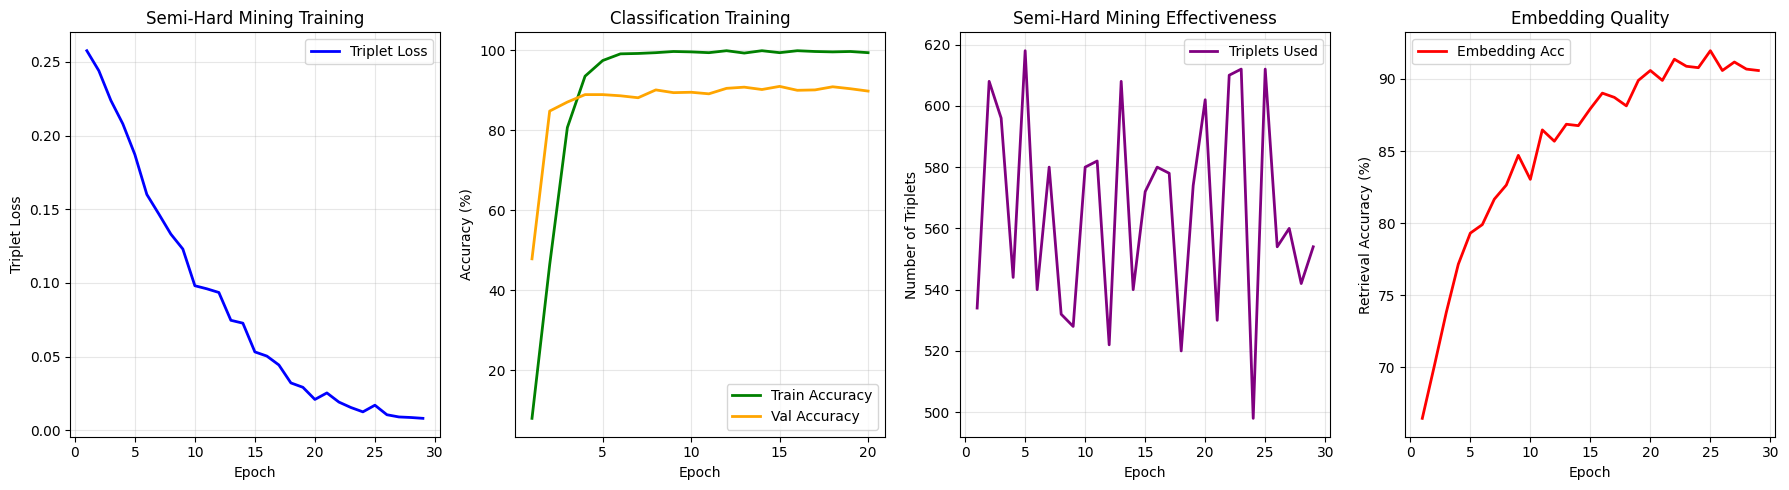

FINAL TEST ACCURACY: 88.08%
EMBEDDING RETRIEVAL ACCURACY: 93.20%
BEST VALIDATION ACCURACY: 90.98%
STRATEGY: Semi-Hard Mining + Classification Head
MARGIN: 0.3
EMBEDDING DIM: 512

PERFORMANCE SUMMARY:
   Semi-Hard Training: 29 epochs
   Classification Training: 20 epochs
   Average Triplets per Epoch: 566
   Final Train Accuracy: 99.41%
   Final Val Accuracy: 89.80%
   Final Test Accuracy: 88.08%
   Final Embedding Retrieval: 93.20%


In [ ]:
if __name__ == "__main__":
    main()